# Do hub fields keep new concepts? Held-out gateway-retention test (demo)

This notebook is a runnable walkthrough of the experiment artifact **`method.py`**, the end-to-end orchestrator of a sealed held-out test of two hypotheses about how scientific concepts spread across fields (OpenAlex, 1995–2022):

- **H1:** does the adopting field's frozen 1998–2002 **eigenvector gateway centrality** (`gateway_j`) predict whether a newly adopted concept is **retained** (`R = 1`) in that field? The test asks whether it adds anything beyond a strong baseline `X0`: B5 diffusion covariates, field size, relatedness `phi(home, j)`, relatedness density, the field's leave-concept-out retention propensity `P_j(-c)`, coverage and episode size.
- **H3:** does gateway-weighted early landing `G` predict size-adjusted breadth? This notebook reports the full-run H3 numbers only.

The full pipeline starts from a scan of all 2,040 OpenAlex works files (476M works, 617 MB of intermediate scan output). That can't run in Colab. The notebook therefore:

1. Shows the orchestrator's step table (`STEPS` / `main()` from `method.py`, unchanged).
2. Re-runs the **core H1 model step** (`models.py dev`: L2 logistic `X0` vs `X1 = X0 + gateway_j`, leave-one-home-group-out out-of-fold ΔAUC, concept-clustered refit bootstrap, relatedness head-to-head and the explanatory baseline ladder). It runs on **100 real DEV episodes** taken from the artifact's output (`full_method_out.json`). The model code is copied from `models.py` without changes.
3. Compares the demo numbers with the full-run results. In the full run, H1 is **DISCONFIRMED**: held-out ΔAUC is −0.00001 [−0.0006, +0.0003].

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the original code logs through loguru)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn (+joblib), matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original imports of method.py ---
from __future__ import annotations

import argparse
import subprocess
import sys
import time

# --- original imports of models.py (the H1 analysis step the orchestrator calls) ---
import hashlib
import json
import math
import warnings

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy import stats
from sklearn.metrics import roc_auc_score

# --- notebook additions ---
from pathlib import Path
from loguru import logger
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")  # as common.setup_logger

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-2/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata_demo_subset"])
print({ds["dataset"]: len(ds["examples"]) for ds in data["datasets"]})

100 DEV episodes (25 per dev home group CS/Eng/BGM/Med; 10 retained R=1 + 15 not retained R=0), seeded random sample from full_method_out.json dataset episodes_dev_LOGO_oof (9,079 episodes).
{'episodes_dev_LOGO_oof': 100}


## Configuration

All tunable parameters are set here. The original values come from `models.py`: `B_MAIN = 2000` refit-bootstrap draws for the primary ΔAUC CI, `B_SMALL = 500` draws for the rival and ladder CIs, `N_JOBS = 4` and `SEED = 20260928`. The regression constants (`C_REG`, `X0`, `X1`) are part of the frozen spec, so they are fixed and not tunable.

In [5]:
N_EPISODES = 100   # DEV episodes used from mini_demo_data.json (max 100 in the demo file; the full DEV set has 9,079)
B_MAIN = 2000      # refit-bootstrap draws for the primary dAUC CI   (original: 2000)
B_SMALL = 500      # draws for rival head-to-head and ladder CIs     (original: 500)
N_JOBS = 2         # joblib workers (original: 4; Colab has 2 cores)
SEED = 20260928    # common.SEED

## 1. The orchestrator: `method.py`

`method.py` runs every step of the study in order: lexicon → prescreen → full OpenAlex scan → onset candidates → backbones → grounding benchmark, sense filter and precision gate → frame → features → unit tests → DEV analysis + **FREEZE** → **UNSEAL (once)** → held-out scoring (+ H3) → replication → report → variants → independent audit.

A step is skipped when its main output already exists, so the run can resume where it stopped. The seal allows only one unseal. The `STEPS` table and `main()` below are copied from `method.py`. The only change is that `ROOT/RES/SCAN/LOGS` are defined locally here instead of being imported from `common.py`. `main()` is **defined but not called**: every step is a separate script that needs the full repository and the 617 MB scan.

In [6]:
# from common import LOGS, RES, ROOT, SCAN, setup_logger   -> defined locally for the notebook
ROOT = Path(".")
RES, SCAN, LOGS = ROOT / "results", ROOT / "scan", ROOT / "logs"

PY = sys.executable
STEPS = [
    ("lexicon", ["lexicon.py"], ROOT / "lexicon_v0.parquet"),
    ("prescreen_sample", ["prescreen.py", "sample"], SCAN / "sample_titles" / "part_001.parquet"),
    ("prescreen_names", ["prescreen.py", "names"], SCAN / "prescreen_survivors.parquet"),
    ("wikidata", ["wikidata_aliases.py"], SCAN / "wikidata_aliases.json"),
    ("prescreen_aliases", ["prescreen.py", "aliases"], ROOT / "lexicon_v1.parquet"),
    ("scan", ["scan_full.py", "--workers", "5"], None),
    ("merge", ["scan_full.py", "--merge"], SCAN / "agg_counts.parquet"),
    ("onset_match", ["frame.py", "match"], RES / "onset_candidates_match.csv"),
    ("backbones", ["backbones.py"], RES / "backbones.json"),
    ("bench", ["grounding.py", "bench"], ROOT / "grounding_benchmark.csv"),
    ("filter", ["grounding.py", "filter"], ROOT / "grounding_report.json"),
    ("onset_grounded", ["frame.py", "grounded"], RES / "onset_candidates_grounded.csv"),
    ("precision", ["grounding.py", "precision"], ROOT / "grounding_precision.csv"),
    ("frame", ["frame.py", "build"], ROOT / "frame_concepts.csv"),
    ("features", ["features.py"], ROOT / "episode_features.csv"),
    ("tests", ["tests/test_units.py"], RES / "unit_tests_T0.json"),
    ("t1", ["checks.py", "t1"], None),
    ("t3", ["checks.py", "t3"], RES / "p78_agreement.csv"),
    ("dev_freeze", ["models.py", "dev"], ROOT / "frozen_spec.json"),
    ("unseal", ["seal.py", "unseal"], ROOT / "sens_episodes_b5_t0p4.csv"),
    ("heldout", ["models.py", "heldout"], RES / "h3_results.json"),
    ("pigeonhole_fix", ["fix_pigeonhole.py"], None),
    ("replicate", ["checks.py", "replicate"], None),
    ("exploratory_domains", ["exploratory_domains.py"], RES / "exploratory_domain_specificity.json"),
    ("report", ["report.py"], ROOT / "method_out.json"),
    ("variants", ["make_variants.py"], ROOT / "preview_method_out.json"),
    ("audit", ["audit.py"], ROOT / "audit.json"),
    ("audit_placebo", ["audit_placebo.py"], RES / "audit_placebo.json"),
]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default=None)
    ap.add_argument("--only", default=None)
    args = ap.parse_args()
    names = [s[0] for s in STEPS]
    i0 = names.index(args.start) if args.start else 0
    for name, cmd, out in STEPS[i0:]:
        if args.only and name != args.only:
            continue
        forced = bool(args.start or args.only)
        if out is not None and out.exists() and not forced:
            logger.info(f"[skip] {name}: {out.relative_to(ROOT)} exists")
            continue
        t = time.time()
        logger.info(f"[run ] {name}: {' '.join(cmd)}")
        r = subprocess.run([PY] + cmd, cwd=ROOT)
        if r.returncode != 0:
            logger.error(f"{name} failed with exit code {r.returncode}")
            raise SystemExit(r.returncode)
        logger.info(f"[done] {name} in {time.time()-t:.0f}s")
    (LOGS / "method_last_run.txt").write_text(time.strftime("%Y-%m-%d %H:%M:%S"))

# main()  # needs the full repository + OpenAlex scan; not run in this demo

# notebook addition: show the pipeline as a table (the step re-run below is "dev_freeze" = models.py dev)
print(pd.DataFrame([(i + 1, n, "python " + " ".join(c), str(o) if o else "-") for i, (n, c, o) in enumerate(STEPS)],
                   columns=["#", "step", "command", "main output (skip if exists)"]).to_string(index=False))

 #                step                         command                main output (skip if exists)
 1             lexicon               python lexicon.py                          lexicon_v0.parquet
 2    prescreen_sample      python prescreen.py sample         scan/sample_titles/part_001.parquet
 3     prescreen_names       python prescreen.py names            scan/prescreen_survivors.parquet
 4            wikidata      python wikidata_aliases.py                  scan/wikidata_aliases.json
 5   prescreen_aliases     python prescreen.py aliases                          lexicon_v1.parquet
 6                scan python scan_full.py --workers 5                                           -
 7               merge     python scan_full.py --merge                     scan/agg_counts.parquet
 8         onset_match           python frame.py match          results/onset_candidates_match.csv
 9           backbones             python backbones.py                      results/backbones.json
10        

## 2. Episode table (input to `models.py dev`)

In the original step, `models.load_dev()` reads `episode_features.csv`, keeps `split == "DEV"` and adds the leave-concept-out propensity `P_j` with `add_pj`. Each row is one **concept × off-home adopting-field episode**:

- `R`: whether the adopting field retained the concept.
- `group`: the concept's home-field group (CS, Eng, BGM, Med). These four groups are the DEV split; PHYS, LIFEENV, SOC and MATHDEC were sealed as held-out.
- `ci`: concept id (the bootstrap cluster).
- The covariates in `X0`, plus `gateway_j`.

In this notebook, the rows come from the artifact's output `episodes_dev_LOGO_oof`. Its `input` field carries every covariate, with `P_j` already computed on the **full** DEV set. This adapter cell is the one piece of new code. It replaces `pd.read_csv` + `add_pj`, which need the full 9,079-episode table.

In [7]:
ex = data["datasets"][0]["examples"][:N_EPISODES]
rows = []
for e in ex:
    inp = json.loads(e["input"])
    rows.append({"ci": inp["concept_id"], "concept": inp["concept"], "field": inp["adopting_field"],
                 "field_name": inp["adopting_field_name"], "t0": inp["t0"], "group": inp["group"],
                 "split": inp["split"], "R": int(e["output"]), **inp["covariates"],
                 "orig_oof_X0": float(e["predict_baseline"]), "orig_oof_X1": float(e["predict_gateway"])})
dev = pd.DataFrame(rows).reset_index(drop=True)
print(f"{len(dev)} episodes / {dev.ci.nunique()} concepts / R rate {dev.R.mean():.2f}")
print(dev.groupby("group").agg(n=("R", "size"), R=("R", "mean"), concepts=("ci", "nunique")))
dev.head()

100 episodes / 100 concepts / R rate 0.40
        n    R  concepts
group                   
BGM    25  0.4        25
CS     25  0.4        25
Eng    25  0.4        25
Med    25  0.4        25


,ci,concept,field,field_name,t0,group,split,R,logvol,growth_c,...,P_j,label_coverage_early,precision_c,tag_coverage,log_n_early,share_early,growth_j,gateway_j,orig_oof_X0,orig_oof_X1
0,2781020372,On the fly,31,Physics and Astronomy,2004,CS,DEV,1,4.07754,-0.19106,...,0.29989,0.58621,0.875,0.39189,1.79176,0.14706,-1.25276,0.48583,0.149688,0.152546
1,122005561,Anycast,22,Engineering,2004,CS,DEV,1,4.51086,0.43078,...,0.52768,0.65556,1.000,0.96774,2.70805,0.23729,-0.84730,0.24272,0.906989,0.906085
2,13854087,Interaction design,22,Engineering,2009,CS,DEV,1,4.06044,-0.14660,...,0.35732,0.50877,1.000,0.23265,2.30259,0.31034,0.35667,0.24272,0.692670,0.695922
3,85407183,Semantic network,22,Engineering,2005,CS,DEV,1,3.89182,-0.64663,...,0.50351,0.50000,1.000,0.51064,1.38629,0.12500,0.00000,0.24272,0.147659,0.145817
4,49289754,Side channel attack,22,Engineering,2008,CS,DEV,1,4.00733,0.00000,...,0.40290,0.57407,1.000,0.98182,2.07944,0.22581,-0.15415,0.24272,0.554702,0.554909


## 3. Model specification and helpers (from `models.py`, unchanged)

- `X0` is the baseline and `X1 = X0 + gateway_j`.
- `L2Logit` is an exact Newton-IRLS solver for sklearn's L2 logistic objective (C = 1, intercept unpenalised). It reaches the same optimum as `lbfgs`, only faster.
- `Z` standardises the covariates with the DEV mean and SD. A NaN becomes 0, which is the DEV mean after standardisation.
- `logo_oof` makes out-of-fold predictions **leave-one-home-group-out**: it trains on 3 DEV groups and predicts the 4th.
- `_boot_logo` / `boot_logo` implement the **concept-clustered refit bootstrap**. Each draw resamples concepts within each group, refits every fold and recomputes the AUCs.
- `dl_pool` is DerSimonian–Laird random-effects pooling of the per-group ΔAUCs.
- `LADDER` is the pre-registered explanatory ladder: the gateway increment over progressively richer baselines.

In [8]:
DEV_GROUPS = ["CS", "Eng", "BGM", "Med"]          # common.DEV_GROUPS
X0 = ["logvol", "growth_c", "offhome_share", "entropy", "reach", "log_field_size", "phi_home", "density", "P_j",
      "label_coverage_early", "precision_c", "tag_coverage", "log_n_early", "share_early", "growth_j"]
GATE = "gateway_j"
X1 = X0 + [GATE]
C_REG = 1.0

B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
# pre-registered explanatory ladder (reported next to the primary, never used for the verdict): where does the
# gateway increment disappear as the baseline grows from the iteration-1 base to the full X0?
LADDER = {"L1_iter1_base": B5 + ["log_n_early", "share_early", "growth_j", "log_field_size"]}
LADDER["L2_plus_relatedness"] = LADDER["L1_iter1_base"] + ["phi_home", "density"]
LADDER["L3_plus_Pj"] = LADDER["L2_plus_relatedness"] + ["P_j"]
LADDER["L4_full_X0"] = X0
LADDER["L0_size_only"] = ["log_n_early", "share_early", "log_field_size"]


def std_consts(df: pd.DataFrame, cols: list[str]) -> dict:
    return {c: [float(df[c].mean()), float(df[c].std() or 1.0)] for c in cols}


def Z(df: pd.DataFrame, cols: list[str], sc: dict) -> np.ndarray:
    X = np.column_stack([(df[c].to_numpy(float) - sc[c][0]) / (sc[c][1] if sc[c][1] > 0 else 1.0) for c in cols])
    return np.nan_to_num(X, nan=0.0)  # NaN -> dev mean (0 after standardisation)


class L2Logit:
    """Exact Newton-IRLS for sklearn's L2 objective 0.5*||w||^2 + C * sum_i s_i * logloss_i (intercept unpenalised).
    Fast for the ~16 standardised covariates used here; converges to the same optimum as lbfgs."""

    def __init__(self, C: float = C_REG):
        self.C = C

    def fit(self, X: np.ndarray, y: np.ndarray, w: np.ndarray | None = None) -> "L2Logit":
        Xa = np.column_stack([np.ones(len(X)), X])
        s = np.ones(len(X)) if w is None else np.asarray(w, float)
        y = np.asarray(y, float)
        P = np.eye(Xa.shape[1])
        P[0, 0] = 0.0
        b = np.zeros(Xa.shape[1])
        for _ in range(100):
            eta = np.clip(Xa @ b, -35, 35)
            p = 1 / (1 + np.exp(-eta))
            g = self.C * Xa.T @ (s * (p - y)) + P @ b
            H = self.C * (Xa * (s * p * (1 - p))[:, None]).T @ Xa + P
            step = np.linalg.solve(H, g)
            b -= step
            if np.abs(step).max() < 1e-10:
                break
        self.coef_, self.intercept_ = b[1:][None, :], np.array([b[0]])
        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X @ self.coef_[0] + self.intercept_[0]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        p = 1 / (1 + np.exp(-np.clip(self.decision_function(X), -35, 35)))
        return np.column_stack([1 - p, p])


def fit(X: np.ndarray, y: np.ndarray, w: np.ndarray | None = None) -> L2Logit:
    return L2Logit(C_REG).fit(X, y, w)


def auc(y, p, w=None) -> float:
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return math.nan
    return float(roc_auc_score(y, p, sample_weight=w))


def logo_oof(df: pd.DataFrame, cols: list[str], sc: dict, y: np.ndarray, groups: np.ndarray,
             w: np.ndarray | None = None) -> np.ndarray:
    X = Z(df, cols, sc)
    oof = np.full(len(df), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if len(np.unique(y[tr])) < 2:
            continue
        m = fit(X[tr], y[tr], None if w is None else w[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    return oof


def dl_pool(est: list[float], se: list[float]) -> dict:
    y = np.array(est, float)
    v = np.array(se, float) ** 2
    ok = np.isfinite(y) & np.isfinite(v) & (v > 0)
    y, v = y[ok], v[ok]
    k = len(y)
    if k == 0:
        return {"k": 0}
    w = 1 / v
    ybar = (w * y).sum() / w.sum()
    Q = float((w * (y - ybar) ** 2).sum())
    tau2 = max(0.0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0.0
    ws = 1 / (v + tau2)
    mu = float((ws * y).sum() / ws.sum())
    se_mu = float(math.sqrt(1 / ws.sum()))
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 and k > 1 else 0.0
    return {"k": k, "pooled": mu, "se": se_mu, "ci95": [mu - 1.96 * se_mu, mu + 1.96 * se_mu], "tau2": tau2,
            "I2": I2, "Q": Q}


def concept_index(df: pd.DataFrame) -> dict:
    return {c: np.nonzero(df.ci.to_numpy() == c)[0] for c in np.unique(df.ci)}


# ----------------------------------------------------------------------------- dev: LOGO + refit bootstrap
def _boot_logo(seed: int, df: pd.DataFrame, specs: dict, sc: dict, y: np.ndarray, grp: np.ndarray,
               cidx: dict, cgrp: dict) -> dict:
    rng = np.random.default_rng(seed)
    rows = []
    for g in DEV_GROUPS:
        cs = cgrp[g]
        pick = rng.choice(cs, size=len(cs), replace=True)
        rows.append(np.concatenate([cidx[c] for c in pick]))
    idx = np.concatenate(rows)
    d = df.iloc[idx]
    yy, gg = y[idx], grp[idx]
    out = {}
    for name, cols in specs.items():
        out[name] = logo_oof(d, cols, sc, yy, gg)
    res = {name: auc(yy, p) for name, p in out.items()}
    res["per_group"] = {g: {name: auc(yy[gg == g], out[name][gg == g]) for name in specs} for g in DEV_GROUPS}
    return res


def boot_logo(df, specs, sc, y, grp, B, seed0):
    cidx = concept_index(df)
    cg = df.groupby("ci").group.first()
    cgrp = {g: cg.index[cg == g].to_numpy() for g in DEV_GROUPS}
    return Parallel(n_jobs=N_JOBS, batch_size=8)(delayed(_boot_logo)(seed0 + b, df, specs, sc, y, grp, cidx, cgrp)
                                                 for b in range(B))


def ci95(a) -> list[float]:
    a = np.asarray([x for x in a if np.isfinite(x)])
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))] if len(a) else [math.nan, math.nan]


def logo_dauc(df, sc, y, grp, gate_col=GATE, base=None) -> dict:
    base = base if base is not None else logo_oof(df, X0, sc, y, grp)
    p1 = logo_oof(df, X0 + [gate_col], sc, y, grp)
    return {"auc0": auc(y, base), "auc1": auc(y, p1), "dauc": auc(y, p1) - auc(y, base), "p0": base, "p1": p1}

## 4. Primary DEV analysis: LOGO out-of-fold ΔAUC with a refit bootstrap

This cell follows the first half of `models.cmd_dev()`. It standardises with the DEV constants (the full run also standardises extra gateway variants that aren't used here), computes LOGO out-of-fold predictions for `X0` and `X1`, and reports ΔAUC = AUC(X1) − AUC(X0), overall and per home group. It then runs the concept-clustered refit bootstrap (`B_MAIN` draws) and pools the per-group ΔAUCs with DerSimonian–Laird.

In [9]:
t_start = time.time()
y = dev.R.to_numpy(int)
grp = dev.group.to_numpy()
sc = std_consts(dev, X1)   # original: X1 + ["gateway_js", "gateway_deg", "gateway_btw", "gateway_phimin", "gateway_S0rec", "log_field_size_s"]
res = {"n_episodes": len(dev), "n_concepts": int(dev.ci.nunique()), "R_rate": float(y.mean()),
       "by_group": dev.groupby("group").agg(n=("R", "size"), R=("R", "mean"), concepts=("ci", "nunique")).to_dict("index")}
logger.info(f"DEV: {res['n_episodes']} episodes / {res['n_concepts']} concepts, R rate {y.mean():.3f}")
base = logo_oof(dev, X0, sc, y, grp)
prim = logo_dauc(dev, sc, y, grp, base=base)
res["primary"] = {"auc_X0": prim["auc0"], "auc_X1": prim["auc1"], "dauc": prim["dauc"],
                  "per_group": {g: {"auc_X0": auc(y[grp == g], prim["p0"][grp == g]),
                                    "auc_X1": auc(y[grp == g], prim["p1"][grp == g]),
                                    "dauc": auc(y[grp == g], prim["p1"][grp == g]) - auc(y[grp == g], prim["p0"][grp == g]),
                                    "n": int((grp == g).sum())} for g in DEV_GROUPS}}
dev["oof_X0"], dev["oof_X1"] = prim["p0"], prim["p1"]
logger.info(f"DEV primary dAUC={prim['dauc']:+.4f} (AUC0 {prim['auc0']:.3f})")
# refit bootstrap (2,000) -- also carries the rival head-to-head models (paired)
t = time.time()
bs = boot_logo(dev, {"X0": X0, "X1": X1}, sc, y, grp, B_MAIN, SEED)
d_boot = [b["X1"] - b["X0"] for b in bs]
res["primary"]["boot_ci95"] = ci95(d_boot)
res["primary"]["boot_sd"] = float(np.nanstd(d_boot))
res["primary"]["boot_p_le0"] = float(np.mean(np.array(d_boot) <= 0))
for g in DEV_GROUPS:
    gd = [b["per_group"][g]["X1"] - b["per_group"][g]["X0"] for b in bs]
    res["primary"]["per_group"][g]["boot_se"] = float(np.nanstd(gd))
res["primary"]["dl_pool_groups"] = dl_pool([res["primary"]["per_group"][g]["dauc"] for g in DEV_GROUPS],
                                           [res["primary"]["per_group"][g]["boot_se"] for g in DEV_GROUPS])
logger.info(f"bootstrap done in {time.time()-t:.0f}s; CI {res['primary']['boot_ci95']}")

21:08:50|INFO   |DEV: 100 episodes / 100 concepts, R rate 0.400


21:08:50|INFO   |DEV primary dAUC=-0.0042 (AUC0 0.819)


21:09:04|INFO   |bootstrap done in 15s; CI [-0.028941410800856902, 0.022733539438502513]


## 5. Rival head-to-head and explanatory ladder

**Rival head-to-head:** start from a reduced baseline `Xr` (X0 without `phi_home` and `density`). Compare adding the **relatedness pair** with adding **`gateway_j`**, using a paired bootstrap with `B_SMALL` draws.

**Ladder:** the gateway increment over progressively richer baselines. In the full run, gateway's +0.0019 over the iteration-1 base disappears once `P_j` (the field's own retention propensity) enters. This suggests gateway centrality mostly stands in for "fields that keep things".

**Gateway alone:** the AUC of `gateway_j` used by itself as a score.

In [10]:
Xr = [c for c in X0 if c not in ("phi_home", "density")]
bsr = boot_logo(dev, {"Xr": Xr, "Xr_rel": Xr + ["phi_home", "density"], "Xr_gw": Xr + [GATE]}, sc, y, grp,
                B_SMALL, SEED + 3)
rel = [b["Xr_rel"] - b["Xr"] for b in bsr]
gw = [b["Xr_gw"] - b["Xr"] for b in bsr]
base_r = logo_oof(dev, Xr, sc, y, grp)
p_rel = logo_oof(dev, Xr + ["phi_home", "density"], sc, y, grp)
p_gw = logo_oof(dev, Xr + [GATE], sc, y, grp)
res["rival_head_to_head"] = {"dauc_relatedness_pair": auc(y, p_rel) - auc(y, base_r),
                             "dauc_gateway": auc(y, p_gw) - auc(y, base_r),
                             "diff_gateway_minus_relatedness": (auc(y, p_gw) - auc(y, p_rel)),
                             "diff_boot_ci95": ci95(np.subtract(gw, rel)),
                             "relatedness_boot_ci95": ci95(rel), "gateway_boot_ci95": ci95(gw)}
# explanatory ladder (dev, LOGO, 500-draw refit bootstrap each)
res["ladder"] = {}
for nm, cols in LADDER.items():
    b0 = logo_oof(dev, cols, sc, y, grp)
    b1 = logo_oof(dev, cols + [GATE], sc, y, grp)
    bl = boot_logo(dev, {"a": cols, "b": cols + [GATE]}, sc, y, grp, B_SMALL, SEED + 5)
    res["ladder"][nm] = {"cols": cols, "auc_base": auc(y, b0), "dauc": auc(y, b1) - auc(y, b0),
                         "ci95": ci95([x["b"] - x["a"] for x in bl])}
res["gateway_alone_auc"] = auc(y, dev[GATE].to_numpy())
logger.info(f"rival + ladder done; total analysis time {time.time()-t_start:.0f}s")

21:09:25|INFO   |rival + ladder done; total analysis time 36s


## 6. Results: demo subset vs the full run

The tables and figures put the numbers from the 100-episode demo next to the artifact's full-run numbers: DEV with 9,079 episodes, and the sealed held-out groups with 8,515 episodes. With only 100 episodes, the demo CIs are wide. The point of the demo is the method and the shape of the result, not the precision.

The last cell also checks that the notebook's LOGO pipeline is consistent with the original. It compares the demo out-of-fold predictions with the full-run out-of-fold predictions stored for the same episodes. The two are not expected to be equal, because the demo trains on 75 episodes rather than ~6,800. They should, however, be positively correlated.

In [11]:
M = data["metadata"]
P = res["primary"]
print("=== H1 primary (DEV, leave-one-home-group-out) ===")
tab = pd.DataFrame({
    "demo (100 DEV episodes)": [P["auc_X0"], P["auc_X1"], P["dauc"], f"[{P['boot_ci95'][0]:+.4f}, {P['boot_ci95'][1]:+.4f}]", res["gateway_alone_auc"]],
    "full run DEV (9,079)": [np.nan, np.nan, M["H1_dev"]["dauc"], f"[{M['H1_dev']['ci95'][0]:+.4f}, {M['H1_dev']['ci95'][1]:+.4f}]", M["gateway_alone_auc"]["dev"]],
    "full run HELD-OUT (8,515)": [M["H1_heldout"]["auc_X0"], M["H1_heldout"]["auc_X1"], M["H1_heldout"]["dauc"],
                                  f"[{M['H1_heldout']['ci95'][0]:+.4f}, {M['H1_heldout']['ci95'][1]:+.4f}]", M["gateway_alone_auc"]["heldout"]],
}, index=["AUC X0 (baseline)", "AUC X1 (+gateway)", "dAUC", "95% bootstrap CI", "gateway-alone AUC"])
print(tab.to_string())
print("\nDemo per-group:")
print(pd.DataFrame(P["per_group"]).T.round(4).to_string())
print("\nDemo DL pooled dAUC:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in P["dl_pool_groups"].items() if k != "ci95"})
print("Full-run held-out verdict:", M["H1_heldout"]["verdict"]["verdict"])
print("\n=== Rival head-to-head (demo) ===")
print(json.dumps({k: v for k, v in res["rival_head_to_head"].items()}, indent=1, default=float))
print("Full-run held-out: relatedness", round(M["H1_heldout"]["rival_head_to_head"]["dauc_relatedness_pair"], 4),
      "vs gateway", round(M["H1_heldout"]["rival_head_to_head"]["dauc_gateway"], 5))
print("\n=== H3 held-out partial Spearman (full run only) ===")
print(pd.DataFrame({k: M["H3_heldout"][k] for k in ["G", "G_A", "G_btw", "REL_home"]}).T[["partial_rho", "p"]].round(4).to_string(),
      "\nverdict:", M["H3_heldout"]["verdict_qualified"])

=== H1 primary (DEV, leave-one-home-group-out) ===
                  demo (100 DEV episodes) full run DEV (9,079) full run HELD-OUT (8,515)
AUC X0 (baseline)                 0.81875                  NaN                  0.837265
AUC X1 (+gateway)                0.814583                  NaN                  0.837256
dAUC                            -0.004167             0.000014                 -0.000009
95% bootstrap CI       [-0.0289, +0.0227]   [-0.0007, +0.0005]        [-0.0006, +0.0003]
gateway-alone AUC                0.619792             0.605444                  0.505695

Demo per-group:
     auc_X0  auc_X1    dauc     n  boot_se
CS   0.5733  0.5733  0.0000  25.0   0.0223
Eng  0.8667  0.8667  0.0000  25.0   0.0310
BGM  0.9133  0.8933 -0.0200  25.0   0.0265
Med  0.9600  0.9667  0.0067  25.0   0.0177

Demo DL pooled dAUC: {'k': 4, 'pooled': -0.0009, 'se': 0.0114, 'tau2': 0.0, 'I2': 0.0, 'Q': 0.7044}
Full-run held-out verdict: DISCONFIRMED

=== Rival head-to-head (demo) ===
{
 "dau

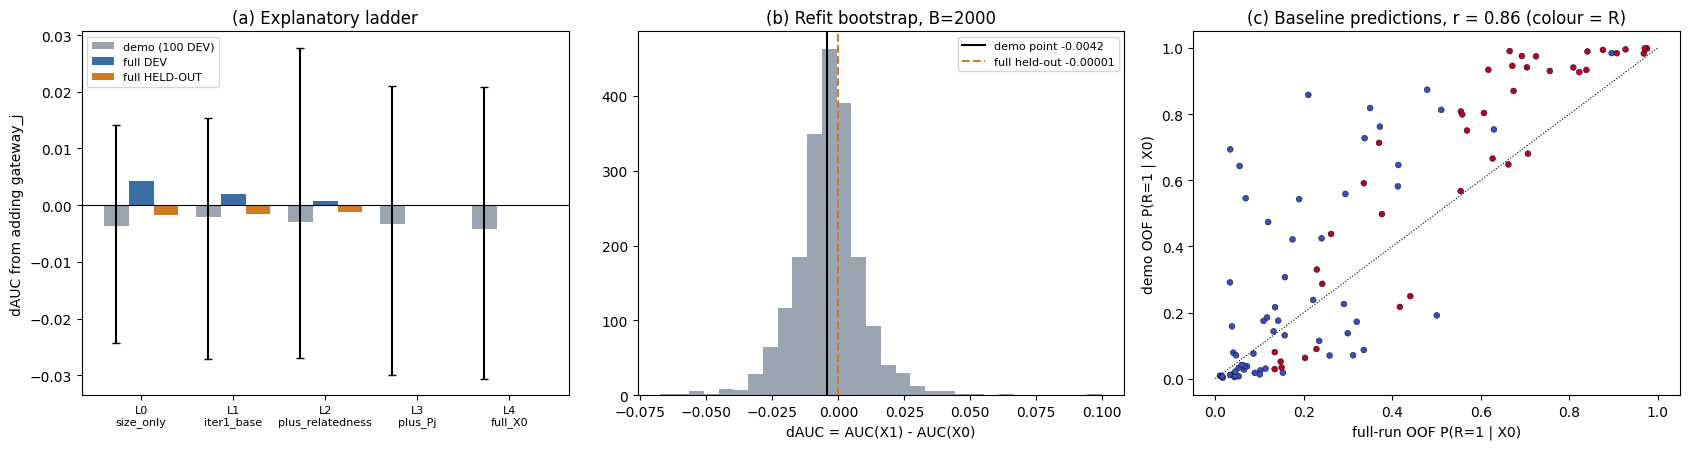

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) ladder: gateway increment over progressively richer baselines
names = ["L0_size_only", "L1_iter1_base", "L2_plus_relatedness", "L3_plus_Pj", "L4_full_X0"]
xx = np.arange(len(names)); w = 0.27
demo = [res["ladder"][n]["dauc"] for n in names]
err = np.array([[res["ladder"][n]["dauc"] - res["ladder"][n]["ci95"][0], res["ladder"][n]["ci95"][1] - res["ladder"][n]["dauc"]] for n in names]).T
ax[0].bar(xx - w, demo, w, yerr=np.clip(err, 0, None), capsize=3, label="demo (100 DEV)", color="#9aa5b1")
ax[0].bar(xx, [M["ladder_dev"][n] for n in names], w, label="full DEV", color="#3b6ea5")
ax[0].bar(xx + w, [M["ladder_heldout"][n] for n in names], w, label="full HELD-OUT", color="#d17a22")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_xticks(xx); ax[0].set_xticklabels([n.replace("_", "\n", 1) for n in names], fontsize=8)
ax[0].set_ylabel("dAUC from adding gateway_j"); ax[0].set_title("(a) Explanatory ladder"); ax[0].legend(fontsize=8)

# (b) bootstrap distribution of the demo primary dAUC
ax[1].hist([d for d in d_boot if np.isfinite(d)], bins=30, color="#9aa5b1")
ax[1].axvline(P["dauc"], color="k", lw=1.5, label=f"demo point {P['dauc']:+.4f}")
ax[1].axvline(M["H1_heldout"]["dauc"], color="#d17a22", ls="--", label=f"full held-out {M['H1_heldout']['dauc']:+.5f}")
ax[1].set_xlabel("dAUC = AUC(X1) - AUC(X0)"); ax[1].set_title(f"(b) Refit bootstrap, B={len(d_boot)}"); ax[1].legend(fontsize=8)

# (c) demo LOGO OOF predictions vs the original full-run OOF predictions for the same episodes
ax[2].scatter(dev.orig_oof_X0, dev.oof_X0, c=dev.R, cmap="coolwarm", s=18, edgecolor="k", lw=0.3)
r = np.corrcoef(dev.orig_oof_X0, dev.oof_X0)[0, 1]
ax[2].plot([0, 1], [0, 1], "k:", lw=0.8)
ax[2].set_xlabel("full-run OOF P(R=1 | X0)"); ax[2].set_ylabel("demo OOF P(R=1 | X0)")
ax[2].set_title(f"(c) Baseline predictions, r = {r:.2f} (colour = R)")
plt.tight_layout(); plt.show()